In [1]:
!pip install netCDF4
!pip install pysolar

     |████████████████████████████████| 51kB 4.4MB/s 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysolar.solar import *
import datetime

from google.colab import files

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Dense, Dropout, Reshape, Flatten, \
    LSTM, GRU, Concatenate, BatchNormalization, TimeDistributed, RepeatVector
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

tf.test.gpu_device_name()
print(tf.__version__)

2.5.0


In [3]:
from datetime import datetime, timedelta
from netCDF4 import Dataset

from google.colab import drive, files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
# Model Data
model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/model_data_new.npy') 

# Obs Data
obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/obs_data_new.npy') 

In [5]:
# Extract the individual features
obs_data_T = obs_data[:,2]
model_data_T = model_data[:,:,1]

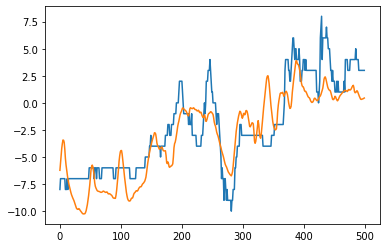

In [6]:
plt.plot(obs_data_T[500:1000])
plt.plot(model_data_T[500:1000,0])

In [7]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 48
future_target = 1

In [8]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(obs_data_T))
print(TRAIN_SPLIT)

157687


In [9]:
def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)


def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [10]:
# Bin the data
obs_data_binned = obs_data_T.copy()

bins = np.arange(obs_data_T.min()-2, obs_data_T.max()+2,2)
obs_data_binned = pd.cut(obs_data_binned, bins, labels=[i for i in range(len(bins)-1)]).to_numpy()

In [11]:
STEP = 1

# This is the visibility (target) dataset
x_train_T_obs, y_train_T = multivariate_data_obs(obs_data_T, obs_data_T, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T_obs, y_val_T = multivariate_data_obs(obs_data_T, obs_data_T,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

x_trained_binned_T, y_train_binned_T = multivariate_data_obs(obs_data_binned, obs_data_binned, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_binned_T, y_val_binned_T = multivariate_data_obs(obs_data_binned, obs_data_binned,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)


# These are the auxiliary datasets
x_train_T_model, _ = multivariate_data_model(model_data_T, model_data_T, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T_model, _ = multivariate_data_model(model_data_T, model_data_T,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [12]:
# Normalize the feature
T_max = np.max(x_train_T_obs) 
T_min = np.min(x_train_T_obs) 

x_train_T_obs = (x_train_T_obs - T_min)/(T_max - T_min)
x_val_T_obs = (x_val_T_obs - T_min)/(T_max - T_min)

x_train_T_model = (x_train_T_model - T_min)/(T_max - T_min)
x_val_T_model = (x_val_T_model - T_min)/(T_max - T_min)

In [13]:
print(obs_data_binned.max())

27


In [14]:
# Concatenate the data
x_train_model = x_train_T_model
x_val_model = x_val_T_model

x_train_obs = x_train_T_obs
x_val_obs = x_val_T_obs

In [15]:
print(x_train_model.shape)
print(x_train_obs.shape)

(157639, 49, 4)
(157639, 48)


In [16]:
# Total number of model features
nr_features_model = 4
nr_features_obs = 1

In [17]:
# Data shape
print ('Single window of past history : {}'.format(x_train_model[0].shape))
print ('Target visibility to predict : {}'.format(y_train_T[0].shape))

Single window of past history : (49, 4)
Target visibility to predict : (1,)


In [18]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:])

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, 
                                                              y_pred_step_i)
  return loss

In [19]:
input_shape_model = (past_history+future_target, nr_features_model,)
input_shape_obs = (past_history, nr_features_obs,)

# Obs branch
in_obs = Input(shape=input_shape_obs)
b_obs = LSTM(128, return_sequences=False, recurrent_dropout=0.0, 
                   dropout=0.)(in_obs)

# Model branch
in_model = Input(shape=input_shape_model)
b_model = LSTM(64, return_sequences=False, recurrent_dropout=0.0, 
                   dropout=0.)(in_model)               

# Now concatenate with all branches
b = Concatenate()([b_obs, b_model])

b = Dense(32*future_target, activation='relu')(b)
b = Dropout(0.3)(b)
b = Reshape((future_target, 32))(b)
b = LSTM(64, return_sequences=True)(b)
out = TimeDistributed(Dense(len(bins)-1, activation='softmax'))(b)

model = Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss=multi_layer_cross_entropy, metrics=['acc'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 48, 1)]      0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 49, 4)]      0                                            
__________________________________________________________________________________________________
lstm (LSTM)                     (None, 128)          66560       input_1[0][0]                    
__________________________________________________________________________________________________
lstm_1 (LSTM)                   (None, 64)           17664       input_2[0][0]                    
______________________________________________________________________________________________

In [20]:
multi_step_history = model.fit([x_train_obs, x_train_model], 
                               y_train_binned_T, batch_size=256,
                               validation_split=0.05, epochs=40,
                               callbacks=tf.keras.callbacks.EarlyStopping(patience=5))

Epoch 1/40
585/585 [==============================] - 17s 13ms/step - loss: 2.0804 - acc: 0.2459 - val_loss: 1.4215 - val_acc: 0.4239
Epoch 2/40
585/585 [==============================] - 6s 11ms/step - loss: 1.3484 - acc: 0.4381 - val_loss: 1.0371 - val_acc: 0.5998
Epoch 3/40
585/585 [==============================] - 6s 11ms/step - loss: 1.1096 - acc: 0.5361 - val_loss: 0.9141 - val_acc: 0.6354
Epoch 4/40
585/585 [==============================] - 6s 11ms/step - loss: 0.9894 - acc: 0.5900 - val_loss: 0.8160 - val_acc: 0.6925
Epoch 5/40
585/585 [==============================] - 6s 11ms/step - loss: 0.9171 - acc: 0.6208 - val_loss: 0.8162 - val_acc: 0.6648
Epoch 6/40
585/585 [==============================] - 6s 11ms/step - loss: 0.8717 - acc: 0.6397 - val_loss: 0.7268 - val_acc: 0.7304
Epoch 7/40
585/585 [==============================] - 6s 11ms/step - loss: 0.8319 - acc: 0.6593 - val_loss: 0.7227 - val_acc: 0.7253
Epoch 8/40
585/585 [==============================] - 6s 11ms/step -

In [21]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.semilogy(epochs, loss, 'b', label='Training loss')
  plt.semilogy(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

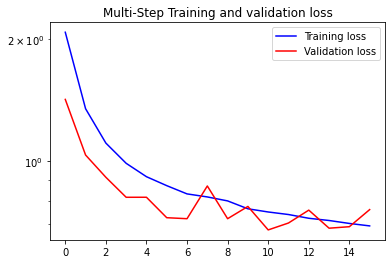

In [22]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

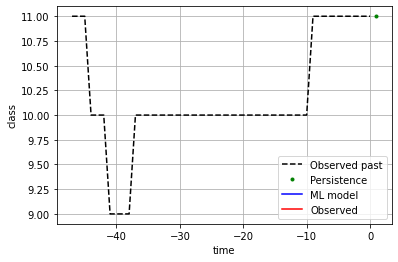

In [23]:
# Plot some results
ix = np.random.randint(0, len(x_val_T_obs))

vis = np.expand_dims(x_val_binned_T[ix,], axis=0)
true_vis = np.expand_dims(y_val_binned_T[ix,], axis=0)

data_obs = np.expand_dims(x_val_obs[ix,], axis=0)
data_model = np.expand_dims(x_val_model[ix,], axis=0)

vis_mean = model([data_obs, data_model])
vis_mean = tf.argmax(vis_mean, axis=2)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_val_binned_T[ix, past_history-1]*np.ones(future_target),'g.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

In [24]:
# Proper verification
from sklearn.metrics import *

In [25]:
# Now verify the model
# 1) Persistence error
y_pers = np.repeat(np.expand_dims(x_val_binned_T[:, past_history-1], axis=1), future_target, axis=1)
err_pers = np.mean(np.square(y_pers - y_val_binned_T), axis=0)

# 3) ML model error
y_ml = model([x_val_obs, x_val_model]) 
y_ml = tf.argmax(y_ml, axis=2) 
err_ml = np.mean(np.square(y_ml - y_val_binned_T), axis=0)

print('Persistence error: {}'.format(err_pers))
print('ML model error: {}'.format(err_ml))

Persistence error: [0.24278059]
ML model error: [0.37030452]


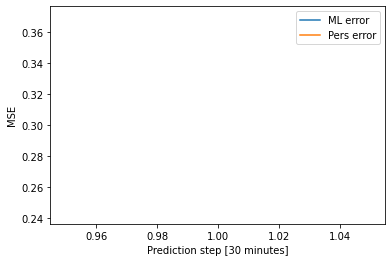

In [33]:
plt.plot(np.arange(1,future_target+1,1), err_ml)
plt.plot(np.arange(1,future_target+1,1), err_pers)
plt.xlabel('Prediction step [30 minutes]')
plt.ylabel('MSE')
plt.legend(['ML error','Pers error'])

In [27]:
nr_classes = len(bins)

precision_pers = np.zeros((nr_classes,future_target))
recall_pers = np.zeros((nr_classes,future_target))
f1_pers = np.zeros((nr_classes,future_target))
balanced_acc_pers = np.zeros(future_target)

precision_ml = np.zeros((nr_classes,future_target))
recall_ml = np.zeros((nr_classes,future_target))
f1_ml = np.zeros((nr_classes,future_target))
balanced_acc_ml = np.zeros(future_target)

for i in range(future_target):
  precision_pers[:,i] = precision_score(y_val_binned_T[:,i], y_pers[:,i], 
                                        labels=bins, average=None)
  precision_ml[:,i] = precision_score(y_val_binned_T[:,i], y_ml[:,i], 
                                        labels=bins, average=None)

  recall_pers[:,i] = recall_score(y_val_binned_T[:,i], y_pers[:,i], 
                                        labels=bins, average=None)
  recall_ml[:,i] = recall_score(y_val_binned_T[:,i], y_ml[:,i], 
                                        labels=bins, average=None)

  f1_pers[:,i] = f1_score(y_val_binned_T[:,i], y_pers[:,i], 
                                        labels=bins, average=None)
  f1_ml[:,i] = f1_score(y_val_binned_T[:,i], y_ml[:,i], 
                                        labels=bins, average=None)
  
  balanced_acc_pers[i] = accuracy_score(y_val_binned_T[:,i], y_pers[:,i])
  balanced_acc_ml[i] = accuracy_score(y_val_binned_T[:,i], y_ml[:,i])

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1515: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  average, "true nor predicted", 'F-score is', len(true_sum)


In [28]:
def categorical_skill_scores(y_true, y_pred, labels):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=labels)
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [29]:
np.set_printoptions(precision=2)
for i in range(future_target):
  HSS, PSS = categorical_skill_scores(y_val_binned_T[:,i], y_ml[:,i], bins)
  print('Prediction step {}:'.format(i+1))
  print('F1-score ML: {}'.format(f1_ml[:,i]))
  print('F1-score PE: {}'.format(f1_pers[:,i]))
  print('Accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_val_binned_T[:,i], y_pers[:,i], bins)
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction step 1:
F1-score ML: [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.48 0.63 0.67
 0.63 0.73 0.78 0.71 0.69 0.67 0.56 0.   0.   0.   0.   0.   0.   0.
 0.  ]
F1-score PE: [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.91 0.82 0.79 0.87
 0.81 0.8  0.76 0.75 0.72 0.7  0.72 0.78 0.64 0.   0.   0.   0.   0.
 0.  ]
Accuracy ML: 0.69
Accuracy PE: 0.78
Heidke skill score ML: 0.9690399201344184
Peirce skill score ML: 0.9680624689290332
Heidke skill score PE: 0.9934759445379667
Peirce skill score PE: 0.9935239820110185



In [30]:
for i in range(future_target):
  print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_val_binned_T[:,i], y_ml[:,i], labels=bins))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_val_binned_T[:,i], y_ml[:,i], labels=bins))
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_val_binned_T[:,i], y_pers[:,i], labels=bins))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_val_binned_T[:,i], y_pers[:,i], labels=bins))  
  print('\n')

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

       -18.0       0.00      0.00      0.00         0
       -16.0       0.00      0.00      0.00         0
       -14.0       0.00      0.00      0.00         0
       -12.0       0.00      0.00      0.00         0
       -10.0       0.00      0.00      0.00         0
        -8.0       0.00      0.00      0.00         0
        -6.0       0.00      0.00      0.00         0
        -4.0       0.00      0.00      0.00         0
        -2.0       0.00      0.00      0.00         0
         0.0       0.00      0.00      0.00         1
         2.0       0.00      0.00      0.00        43
         4.0       0.45      0.51      0.48        84
         6.0       0.73      0.55      0.63       385
         8.0       0.76      0.59      0.67      2681
        10.0       0.65      0.62      0.63      2758
        12.0       0.69      0.78      0.73      2967
        14.0       0.77     

In [31]:
'''
Classification summary ML model at forecast hour 1 (Single time prediction):

              precision    recall  f1-score   support

       -18.0       0.00      0.00      0.00         0
       -16.0       0.00      0.00      0.00         0
       -14.0       0.00      0.00      0.00         0
       -12.0       0.00      0.00      0.00         0
       -10.0       0.00      0.00      0.00         0
        -8.0       0.00      0.00      0.00         0
        -6.0       0.00      0.00      0.00         0
        -4.0       0.00      0.00      0.00         0
        -2.0       0.00      0.00      0.00         0
         0.0       0.00      0.00      0.00         1
         2.0       0.76      0.79      0.77        43
         4.0       0.62      0.76      0.68        84
         6.0       0.72      0.68      0.70       385
         8.0       0.87      0.79      0.83      2681
        10.0       0.84      0.77      0.80      2758
        12.0       0.84      0.77      0.80      2967
        14.0       0.75      0.80      0.77      2631
        16.0       0.65      0.84      0.73      2490
        18.0       0.72      0.72      0.72      2532
        20.0       0.78      0.70      0.73      1748
        22.0       0.50      0.69      0.58       951
        24.0       0.19      0.08      0.11       292
        26.0       0.00      0.00      0.00        11
        28.0       0.00      0.00      0.00         0
        30.0       0.00      0.00      0.00         0
        32.0       0.00      0.00      0.00         0
        34.0       0.00      0.00      0.00         0
        36.0       0.00      0.00      0.00         0
        38.0       0.00      0.00      0.00         0

   micro avg       0.75      0.75      0.75     19574
   macro avg       0.28      0.29      0.28     19574
weighted avg       0.76      0.75      0.75     19574

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

       -18.0       0.00      0.00      0.00         0
       -16.0       0.00      0.00      0.00         0
       -14.0       0.00      0.00      0.00         0
       -12.0       0.00      0.00      0.00         0
       -10.0       0.00      0.00      0.00         0
        -8.0       0.00      0.00      0.00         0
        -6.0       0.00      0.00      0.00         0
        -4.0       0.00      0.00      0.00         0
        -2.0       0.00      0.00      0.00         0
         0.0       0.00      0.00      0.00         1
         2.0       0.00      0.00      0.00        43
         4.0       0.00      0.00      0.00        84
         6.0       0.50      0.74      0.60       385
         8.0       0.84      0.76      0.80      2681
        10.0       0.82      0.79      0.80      2756
        12.0       0.79      0.82      0.80      2967
        14.0       0.74      0.76      0.75      2631
        16.0       0.70      0.78      0.74      2490
        18.0       0.69      0.73      0.71      2532
        20.0       0.80      0.55      0.65      1748
        22.0       0.56      0.85      0.67       951
        24.0       0.00      0.00      0.00       292
        26.0       0.00      0.00      0.00        11
        28.0       0.00      0.00      0.00         0
        30.0       0.00      0.00      0.00         0
        32.0       0.00      0.00      0.00         0
        34.0       0.00      0.00      0.00         0
        36.0       0.00      0.00      0.00         0
        38.0       0.00      0.00      0.00         0

   micro avg       0.74      0.74      0.74     19572
   macro avg       0.22      0.23      0.22     19572
weighted avg       0.73      0.74      0.73     19572

Classification summary Persistence at forecast hour 1:

              precision    recall  f1-score   support

       -18.0       0.00      0.00      0.00         0
       -16.0       0.00      0.00      0.00         0
       -14.0       0.00      0.00      0.00         0
       -12.0       0.00      0.00      0.00         0
       -10.0       0.00      0.00      0.00         0
        -8.0       0.00      0.00      0.00         0
        -6.0       0.00      0.00      0.00         0
        -4.0       0.00      0.00      0.00         0
        -2.0       0.00      0.00      0.00         0
         0.0       0.00      0.00      0.00         1
         2.0       0.91      0.91      0.91        43
         4.0       0.82      0.82      0.82        84
         6.0       0.79      0.79      0.79       385
         8.0       0.87      0.87      0.87      2681
        10.0       0.81      0.81      0.81      2756
        12.0       0.80      0.80      0.80      2967
        14.0       0.76      0.76      0.76      2631
        16.0       0.75      0.75      0.75      2490
        18.0       0.72      0.72      0.72      2532
        20.0       0.70      0.70      0.70      1748
        22.0       0.72      0.72      0.72       951
        24.0       0.78      0.78      0.78       292
        26.0       0.64      0.64      0.64        11
        28.0       0.00      0.00      0.00         0
        30.0       0.00      0.00      0.00         0
        32.0       0.00      0.00      0.00         0
        34.0       0.00      0.00      0.00         0
        36.0       0.00      0.00      0.00         0
        38.0       0.00      0.00      0.00         0

   micro avg       0.77      0.77      0.77     19572
   macro avg       0.35      0.35      0.35     19572
weighted avg       0.77      0.77      0.77     19572

Classification summary ML model at forecast hour 2:

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
              precision    recall  f1-score   support

       -18.0       0.00      0.00      0.00         0
       -16.0       0.00      0.00      0.00         0
       -14.0       0.00      0.00      0.00         0
       -12.0       0.00      0.00      0.00         0
       -10.0       0.00      0.00      0.00         0
        -8.0       0.00      0.00      0.00         0
        -6.0       0.00      0.00      0.00         0
        -4.0       0.00      0.00      0.00         0
        -2.0       0.00      0.00      0.00         0
         0.0       0.00      0.00      0.00         1
         2.0       0.50      0.12      0.19        43
         4.0       0.44      0.52      0.48        84
         6.0       0.59      0.68      0.63       385
         8.0       0.80      0.72      0.76      2681
        10.0       0.76      0.76      0.76      2755
        12.0       0.70      0.77      0.73      2967
        14.0       0.68      0.64      0.66      2631
        16.0       0.60      0.77      0.67      2490
        18.0       0.60      0.52      0.56      2532
        20.0       0.70      0.50      0.58      1748
        22.0       0.63      0.71      0.66       951
        24.0       0.08      0.02      0.03       292
        26.0       0.00      0.00      0.00        11
        28.0       0.00      0.00      0.00         0
        30.0       0.00      0.00      0.00         0
        32.0       0.00      0.00      0.00         0
        34.0       0.00      0.00      0.00         0
        36.0       0.00      0.00      0.00         0
        38.0       0.00      0.00      0.00         0

   micro avg       0.68      0.67      0.67     19571
   macro avg       0.24      0.23      0.23     19571
weighted avg       0.68      0.67      0.67     19571

Classification summary Persistence at forecast hour 2:

              precision    recall  f1-score   support

       -18.0       0.00      0.00      0.00         0
       -16.0       0.00      0.00      0.00         0
       -14.0       0.00      0.00      0.00         0
       -12.0       0.00      0.00      0.00         0
       -10.0       0.00      0.00      0.00         0
        -8.0       0.00      0.00      0.00         0
        -6.0       0.00      0.00      0.00         0
        -4.0       0.00      0.00      0.00         0
        -2.0       0.00      0.00      0.00         0
         0.0       0.00      0.00      0.00         1
         2.0       0.84      0.84      0.84        43
         4.0       0.68      0.68      0.68        84
         6.0       0.67      0.67      0.67       385
         8.0       0.79      0.79      0.79      2681
        10.0       0.71      0.71      0.71      2755
        12.0       0.69      0.69      0.69      2967
        14.0       0.61      0.61      0.61      2631
        16.0       0.58      0.58      0.58      2490
        18.0       0.55      0.55      0.55      2532
        20.0       0.51      0.51      0.51      1748
        22.0       0.54      0.54      0.54       951
        24.0       0.61      0.61      0.61       292
        26.0       0.45      0.45      0.45        11
        28.0       0.00      0.00      0.00         0
        30.0       0.00      0.00      0.00         0
        32.0       0.00      0.00      0.00         0
        34.0       0.00      0.00      0.00         0
        36.0       0.00      0.00      0.00         0
        38.0       0.00      0.00      0.00         0

   micro avg       0.64      0.64      0.64     19571
   macro avg       0.28      0.28      0.28     19571
weighted avg       0.64      0.64      0.64     19571
'''


'\nClassification summary ML model at forecast hour 1 (Single time prediction):\n\n              precision    recall  f1-score   support\n\n       -18.0       0.00      0.00      0.00         0\n       -16.0       0.00      0.00      0.00         0\n       -14.0       0.00      0.00      0.00         0\n       -12.0       0.00      0.00      0.00         0\n       -10.0       0.00      0.00      0.00         0\n        -8.0       0.00      0.00      0.00         0\n        -6.0       0.00      0.00      0.00         0\n        -4.0       0.00      0.00      0.00         0\n        -2.0       0.00      0.00      0.00         0\n         0.0       0.00      0.00      0.00         1\n         2.0       0.76      0.79      0.77        43\n         4.0       0.62      0.76      0.68        84\n         6.0       0.72      0.68      0.70       385\n         8.0       0.87      0.79      0.83      2681\n        10.0       0.84      0.77      0.80      2758\n        12.0       0.84      0.77  